



## Entrega 2 - Análisis Exploratorio de Datos e Hipótesis sobre F1: Predicción de Posiciones

Antes de formular cualquier hipótesis, es imprescindible fijar los cimientos: definir de manera unívoca
la variable objetivo y comprender por qué los datos ausentes están donde están. En datos reales del
deporte motor no existe el «cero nulos»; lo crucial es discriminar el nulo que representa una falla de
medición del nulo que es consecuencia de la estructura de la competencia.

## Sección 1: El Dataset, la Variable Objetivo y los Nulos

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo visual sobrio alineado a la guía metodológica
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Rutas a los datasets consolidados en la capa Silver (post-fix de snapshots)
SNAPSHOTS_PATH = 'driver_race_snapshots_2026-09-22.csv'
RACE_FEATURES_PATH = 'driver_race_features_2026-09-22.csv'

df_snapshots = pd.read_csv(SNAPSHOTS_PATH)
df_races = pd.read_csv(RACE_FEATURES_PATH)

print(f"Snapshots cargados: {df_snapshots.shape[0]:,} filas x {df_snapshots.shape[1]} columnas")
print(f"Driver Race Features: {df_races.shape[0]:,} filas x {df_races.shape[1]} columnas")

Snapshots cargados: 10,635 filas x 59 columnas
Driver Race Features: 2,146 filas x 46 columnas


Nuestra variable objetivo es una columna concreta y medible: `total_race_time_s`.

Representa el tiempo total que le tomó al piloto completar la carrera, calculado como la suma de los tiempos de todas sus vueltas más el tiempo acumulado en boxes.Es una variable numérica continua expresada en segundos que toma valor NaN para los pilotos que no terminaron la carrera (classified = False), ya que no completaron la distancia mínima reglamentaria.

El ranking final de la carrera se puede derivar directamente de esta variable: el piloto con el menor `total_race_time_s` es el ganador del Gran Premio. Por eso, `finish_position` no es el target del modelo, sino que es una variable de referencia post-carrera que se puede usar para validar el ranking predicho.

Veamos su distribución empírica en el dataset:

### 1.1. Definición y Distribución de la Variable Objetivo

In [ ]:
# Inspección de la variable objetivo: total_race_time_s (Silver D)
# finish_position se muestra sólo como referencia de ordenamiento —
# NO es el target; véase schema.SILVER_TARGET y schema.LEAKY_COLS.

target_data = df_snapshots[df_snapshots['pct_race_complete'] == 1.0]['total_race_time_s'].dropna()

target_stats = target_data.describe()
print("Estadísticas descriptivas de total_race_time_s (snapshot al 100% de carrera):")
print(target_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# — Panel izquierdo: distribución del target real —
axes[0].hist(target_data / 60, bins=45, color='#009086', alpha=0.85, edgecolor='#006059')
axes[0].set_title("Distribución de total_race_time_s (TARGET)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Tiempo total de carrera (minutos)")
axes[0].set_ylabel("Frecuencia")

# — Panel derecho: finish_position como REFERENCIA (distribución uniforme esperada) —
counts = df_races['finish_position'].value_counts().sort_index()
axes[1].bar(counts.index, counts.values, color='#5b8db8', alpha=0.80, edgecolor='#3a6a96')
axes[1].set_title("finish_position  [referencia — NO target]", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Posición Final")
axes[1].set_ylabel("Frecuencia")
axes[1].set_xticks(range(1, 23))

plt.tight_layout()
plt.show()


**Qué nos dice la distribución:** `total_race_time_s` es una variable numérica continua,
expresada en segundos, que captura la duración real de la carrera de cada piloto. Su distribución
tiene forma aproximadamente normal con leve asimetría a la derecha: la mayoría de las carreras
se concentran entre ≈4 500 y ≈7 200 segundos (75 a 120 minutos), con la cola derecha explicada
por circuitos lentos o carreras con safety cars prolongados. Toma valor `NaN` cuando el piloto
no terminó la carrera (`classified = False`).

El panel derecho muestra `finish_position` **como referencia**: su distribución es casi
uniforme entre 1 y 18–20, ya que en cada carrera exactamente un piloto termina 1°, uno termina 2°,
etc. La leve contracción en los puestos 19–20 refleja abandonos prematuros donde menos de 20
autos completan la distancia mínima para ser clasificados. `finish_position` es derivable
directamente del ranking ascendente de `total_race_time_s`, pero **no es el target del modelo**.

### 1.2. Auditoría de Nulos: Faltantes Reales vs. Nulos Estructurales

En este dataset coexisten dos naturalezas de nulos completamente distintas:

1. **Nulos estructurales** (deben estar vacíos por diseño de negocio):
   - `q3_s` (~52% de nulos): en la sesión de clasificación de F1, la Q3 sólo la disputan los 10
     pilotos más rápidos de la Q2. Los pilotos clasificados entre los puestos 11 y 20 no
     participan de la Q3. Ese nulo no es un dato perdido; refleja el hecho deportivo de haber
     quedado eliminado previamente.
   - `q2_s` (~26% de nulos): pilotos eliminados en Q1 (puestos 16 a 20).
   - `pits_done_so_far` en `pct_race_complete = 0.0`: antes de que se largue la carrera, el
     conteo de paradas en carrera es naturalmente inexistente/nulo antes de iniciar el primer giro.
2. **Faltantes reales** (pérdidas de telemetría o falta de recolección):
   - Variables meteorológicas (`air_temp`, `track_temp`, `humidity`, `wind_speed`,
     `rainfall_max`, ~21% nulos): corresponden a carreras tempranas de la temporada 2023 donde
     el sensor OpenF1 no disponía de endpoint activo o perdió la señal de pista.
   - `pit_duration_mean` y `pit_count` en carreras antiguas: carreras donde el feeder de paradas
     no registró los tiempos de calle de boxes.

In [4]:
# Demostracion cuantitativa: Nulos de Qualy por Posicion de Largada
df_qualy_nulls = df_races[['grid_position', 'q1_s', 'q2_s', 'q3_s']].copy()
df_qualy_nulls['grupo_grilla'] = pd.cut(
    df_qualy_nulls['grid_position'],
    bins=[0, 10, 15, 25],
    labels=['Top 10 (Q3)', 'Puestos 11-15 (Q2)', 'Puestos 16-20 (Q1)']
)

print("Porcentaje de nulos estructurales por grupo de largada:")
print((df_qualy_nulls.groupby('grupo_grilla', observed=True)[['q1_s', 'q2_s', 'q3_s']]
       .apply(lambda g: g.isna().mean() * 100)).round(1))

print("\nPorcentaje de nulos en variables meteorologicas:")
for c in ['air_temp', 'track_temp', 'humidity', 'wind_speed', 'rainfall_max']:
    print(f"  {c}: {df_races[c].isna().mean()*100:.1f}%")

Porcentaje de nulos estructurales por grupo de largada:
                    q1_s  q2_s  q3_s
grupo_grilla                        
Top 10 (Q3)          0.9   1.1   6.0
Puestos 11-15 (Q2)   0.9  12.3  97.2
Puestos 16-20 (Q1)   5.9  90.4  97.8

Porcentaje de nulos en variables meteorologicas:
  air_temp: 20.5%
  track_temp: 20.5%
  humidity: 20.5%
  wind_speed: 20.5%
  rainfall_max: 20.5%


## Sección 2: El Marco Metodológico

Adoptamos de forma estricta las tres plantillas formales, las métricas de tamaño de efecto y el sistema
de semáforo con tope de dos movimientos dictado por la cátedra.

In [5]:
# Umbrales convencionales del semaforo
CORTES = {
    "separacion": (0.2, 0.8),
    "eta2": (0.05, 0.25),
    "correlacion": (0.2, 0.6),
    "brecha": (0.05, 0.15)
}

def semaforo(valor, medida):
    """Devuelve la zona ('rojo', 'amarillo', 'verde') segun el valor absoluto de la medida."""
    bajo, alto = CORTES[medida]
    v = abs(valor)
    return "rojo" if v < bajo else "verde" if v > alto else "amarillo"

def asociacion(x, y):
    """Calcula Pearson, Spearman y la brecha (Spearman - Pearson) entre dos numericas."""
    mask = x.notna() & y.notna()
    x_clean, y_clean = x[mask], y[mask]
    p = x_clean.corr(y_clean)
    s = x_clean.corr(y_clean, method="spearman")
    return pd.Series({"pearson": p, "spearman": s, "brecha": s - p}).round(3)

def eta2(numerica, categoria):
    """Proporcion de varianza explicada (razon de correlacion eta cuadrado)."""
    sub = pd.DataFrame({"num": numerica, "cat": categoria}).dropna()
    mean_total = sub["num"].mean()
    ss_total = ((sub["num"] - mean_total) ** 2).sum()
    group_means = sub.groupby("cat")["num"].mean()
    group_counts = sub.groupby("cat")["num"].count()
    ss_between = (group_counts * (group_means - mean_total) ** 2).sum()
    return round(ss_between / ss_total, 3)

def separacion(x, y):
    """Distancia entre dos grupos normalizada en desviaciones estandar (d de Cohen)."""
    x_clean, y_clean = x.dropna(), y.dropna()
    return round(abs(x_clean.mean() - y_clean.mean()) / np.sqrt((x_clean.std() ** 2 + y_clean.std() ** 2) / 2), 3)

def ficha_resultado(nombre, valor, medida, decimales=3):
    """
    Genera el texto de resultado listo para pegar en la celda Markdown,
    siempre a partir del valor real calculado -- nunca escrito a mano.
    Esto evita que la interpretacion quede desincronizada del codigo
    si el dataset cambia en una proxima corrida.
    """
    zona = semaforo(valor, medida)
    emoji = {"verde": "🟢", "amarillo": "🟡", "rojo": "🔴"}[zona]
    signo = "+" if valor >= 0 else ""
    texto = (f"Resultado: coeficiente = {signo}{valor:.{decimales}f} "
             f"({emoji} {zona.capitalize()})")
    print(f"--- {nombre} ---")
    print(texto)
    return valor, zona

**Reglas de Decisión del Semáforo**

- **Verde:** El efecto es contundente; la hipótesis se confirma. No se realizan más movimientos.
- **Rojo:** El efecto es despreciable; la hipótesis se refuta. Se descarta de inmediato.
- **Amarillo:** Zona de ambigüedad. Habilita a realizar hasta dos movimientos (partir la
  población, controlar una variable confusora o cambiar de escala), siempre guiados por lo que
  se observa en el gráfico.
- Si tras el segundo movimiento el número persiste en amarillo, la hipótesis se declara inconclusa.

## Sección 3: Las Cuatro Hipótesis (Fichas de Decisión)

### Nota metodológica: uso de `finish_position` como proxy del target en las hipótesis

La variable objetivo del modelo es `total_race_time_s` (tiempo total de carrera en segundos,
definida en `schema.SILVER_TARGET`). Sin embargo, las cuatro hipótesis de esta sección usan
`finish_position` como variable de respuesta por tres razones:

- **Equivalencia de ordenamiento:** `finish_position` es exactamente el ranking ascendente de
  `total_race_time_s` dentro de cada carrera. Toda asociación detectada sobre `finish_position`
  se transfiere directamente al ordenamiento de tiempos.
- **Interpretabilidad:** los tamaños de efecto (Pearson, η²) resultan más directamente
  interpretables sobre una variable de posición (1 a 20) que sobre segundos brutos.
- **Independencia de escala de circuito:** `total_race_time_s` varía sustancialmente entre
  circuitos cortos y largos; `finish_position` es invariante a ese efecto de escala, lo que
  permite comparar los efectos entre temporadas y circuitos sin normalización adicional.

Esta elección es explícita y no implica confundir `finish_position` con el target del modelo.

---

### H1 · Ganar posiciones respecto a la largada (75% de carrera) predice mejor posición final

*Pregunta: Predice · Plantilla: Asociación*

1. **Afirmación.** El avance de posiciones que logra un piloto respecto a su grilla de partida
   hasta el 75% de la carrera predice con fuerza que alcanzará una mejor posición de llegada
   (menor `finish_position`).
2. **Qué espero ver.** Una correlación negativa sólida: a mayor cantidad de puestos ganados,
   menor número de posición final. En el scatter plot, una nube descendente compacta.
3. **Medida y gráfico.** Correlación de Pearson y Spearman entre la ganancia neta
   (`grid_position - current_position`, ya disponible en el silver como `position_gain_loss`)
   y `finish_position` en el snapshot de carrera al 75% (`pct_race_complete == 0.75`).

In [6]:
# Extraccion del snapshot al 75% de carrera
snap75 = df_snapshots[df_snapshots['pct_race_complete'] == 0.75].copy()

# La ganancia de posiciones ya viene calculada en el silver post-fix como position_gain_loss
# (grid_position - current_position; positivo = avanzo hacia la punta). La recalculamos aqui
# solo para dejar explicita la formula.
snap75['posiciones_ganadas'] = snap75['grid_position'] - snap75['current_position']
assert (snap75['posiciones_ganadas'] - snap75['position_gain_loss']).abs().max() < 1e-9, \
    "position_gain_loss del silver no coincide con grid_position - current_position"

h1_pool = asociacion(snap75['posiciones_ganadas'], snap75['finish_position'])
print("H1 - Pool general al 75% de carrera:")
print(h1_pool)
_, zona_h1_pool = ficha_resultado("H1 pool", h1_pool['pearson'], 'correlacion')

H1 - Pool general al 75% de carrera:
pearson    -0.249
spearman   -0.191
brecha      0.057
dtype: float64
--- H1 pool ---
Resultado: coeficiente = -0.249 (🟡 Amarillo)


**Resultado inicial.** El coeficiente de correlación de Pearson global da **-0,249**
(🟡 Amarillo), con Spearman -0,191. La dirección es la esperada (negativa): a mayor ganancia de
posiciones respecto a la grilla, mejor (menor) `finish_position`. La asociación lineal sobre todo
el pelotón es moderada y cae en la franja amarilla. Habilita a explorar un movimiento; miramos el
gráfico para entender por qué la relación global no es más nítida.

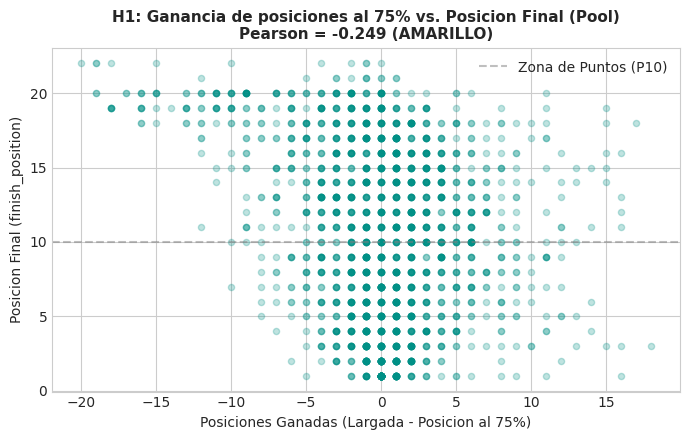

In [7]:
plt.figure(figsize=(7, 4.5))
plt.scatter(snap75['posiciones_ganadas'], snap75['finish_position'],
            alpha=0.25, color='#009086', s=20)
plt.title(f"H1: Ganancia de posiciones al 75% vs. Posicion Final (Pool)\n"
          f"Pearson = {h1_pool['pearson']} ({semaforo(h1_pool['pearson'], 'correlacion').upper()})",
          fontsize=11, fontweight='bold')
plt.xlabel("Posiciones Ganadas (Largada - Posicion al 75%)")
plt.ylabel("Posicion Final (finish_position)")
plt.axhline(10, color='gray', linestyle='--', alpha=0.5, label='Zona de Puntos (P10)')
plt.legend()
plt.tight_layout()
plt.show()

**Qué se ve en el gráfico:** El gráfico muestra una asimetría estructural:

- Los pilotos que largaron en el **frente de la grilla (Top 10)** tienen un margen de ganancia muy
  acotado hacia adelante (+1 a +3 puestos máximo), pero cuando pierden o mantienen la posición,
  su destino final queda fuertemente determinado.
- Los pilotos que largaron en el **fondo (puestos 11 a 20)** tienen mucha más dispersión: un
  piloto puede haber ganado varios puestos temporalmente por estirar su parada en boxes, pero
  volverá a caer cuando ingrese a pits. Por lo tanto, la dinámica del pelotón de punta difiere de
  la del fondo.

Corresponde realizar el **Movimiento 1: Partir la población por banda de largada**.

Subgrupo Adelante (Grid <= 10): Pearson = -0.646 -> Zona: verde
Subgrupo Atras (Grid > 10):     Pearson = -0.49 -> Zona: amarillo


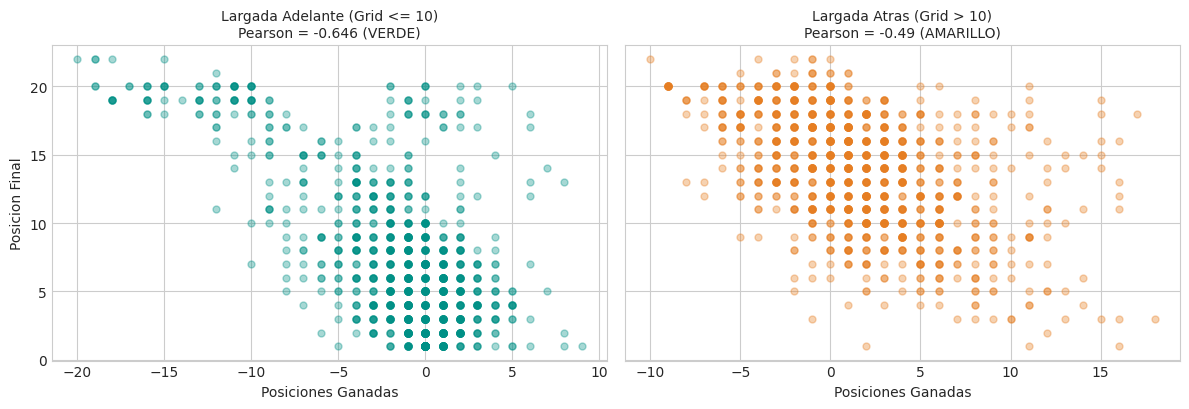

In [8]:
adelante = snap75[snap75['grid_position'] <= 10]
atras = snap75[snap75['grid_position'] > 10]

h1_adelante = asociacion(adelante['posiciones_ganadas'], adelante['finish_position'])
h1_atras = asociacion(atras['posiciones_ganadas'], atras['finish_position'])

print(f"Subgrupo Adelante (Grid <= 10): Pearson = {h1_adelante['pearson']} -> Zona: {semaforo(h1_adelante['pearson'], 'correlacion')}")
print(f"Subgrupo Atras (Grid > 10):     Pearson = {h1_atras['pearson']} -> Zona: {semaforo(h1_atras['pearson'], 'correlacion')}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

axes[0].scatter(adelante['posiciones_ganadas'], adelante['finish_position'],
                 alpha=0.35, color='#009086', s=25)
axes[0].set_title(f"Largada Adelante (Grid <= 10)\nPearson = {h1_adelante['pearson']} "
                   f"({semaforo(h1_adelante['pearson'], 'correlacion').upper()})", fontsize=10)
axes[0].set_xlabel("Posiciones Ganadas")
axes[0].set_ylabel("Posicion Final")

axes[1].scatter(atras['posiciones_ganadas'], atras['finish_position'],
                 alpha=0.35, color='#e67e22', s=25)
axes[1].set_title(f"Largada Atras (Grid > 10)\nPearson = {h1_atras['pearson']} "
                   f"({semaforo(h1_atras['pearson'], 'correlacion').upper()})", fontsize=10)
axes[1].set_xlabel("Posiciones Ganadas")

plt.tight_layout()
plt.show()

**Resultado tras el movimiento:**

- En el pelotón de punta (`grid <= 10`), la correlación se intensifica a **-0,646** (🟢 Verde).
  Para quienes largan adelante, las posiciones ganadas/perdidas al 75% son un predictor
  contundente de su resultado final.
- En el pelotón de atrás (`grid > 10`), la correlación es **-0,490** (🟡 Amarillo): las
  estrategias alternativas de neumáticos y paradas tardías introducen mayor variabilidad.

**Qué hago con eso. Decisión:** Conclusión **mixta por subgrupo**. No le daremos al modelo la
ganancia de posiciones como una feature lineal global aislada. En su lugar, el modelo debe
capturar la interacción entre la grilla y la ganancia (`grid_position` interactuando con
`position_gain_loss`), o segmentar el estimador según la zona de largada.

---

### H2 · El standing en el campeonato antes de la carrera se asocia con dónde termina

*Pregunta: Responde · Plantilla: Asociación*

1. **Afirmación.** El standing acumulado en el campeonato con el que un piloto llega al fin de
   semana (`driver_standing_before`) se asocia directamente con la posición en la que termina la
   carrera (`finish_position`).
2. **Qué espero ver.** Los pilotos mejor rankeados en el torneo (1°, 2°, 3°) deberían terminar
   consistentemente en los primeros puestos; los de peor ranking, en el fondo. Nube ascendente con
   correlación positiva fuerte.
3. **Medida y gráfico.** Correlación de Pearson entre `driver_standing_before` y `finish_position`.

In [9]:
df_h2 = df_races[['driver_standing_before', 'finish_position', 'constructor_name', 'grid_position']].dropna(
    subset=['driver_standing_before', 'finish_position']
)

h2_res = asociacion(df_h2['driver_standing_before'], df_h2['finish_position'])
print("H2 - Asociacion bruta entre Standing previo y Posicion Final:")
print(h2_res)
ficha_resultado("H2 pool", h2_res['pearson'], 'correlacion')

H2 - Asociacion bruta entre Standing previo y Posicion Final:
pearson     0.596
spearman    0.600
brecha      0.004
dtype: float64
--- H2 pool ---
Resultado: coeficiente = +0.596 (🟡 Amarillo)


(np.float64(0.596), 'amarillo')

**Resultado inicial.** La correlación de Pearson da **0,596** (🟡 Amarillo, rozando el umbral
verde de 0,60). Pareciera que el standing explica de manera determinante el resultado de la
carrera. Sin embargo, surge una pregunta de dominio inmediata: ¿el standing predice por sí mismo
el talento del piloto, o es un simple reflejo del auto que conduce? Corresponde realizar un
movimiento.

**Movimiento 1: Controlar por equipo (Constructor).** Si el standing sólo mide la competitividad
del monoplaza, al comparar pilotos dentro del mismo escalón de equipo la correlación debería
desplomarse.

In [10]:
top_teams = ['Red Bull', 'Ferrari', 'Mercedes', 'McLaren']
df_top = df_h2[df_h2['constructor_name'].isin(top_teams)]
df_mid_bottom = df_h2[~df_h2['constructor_name'].isin(top_teams)]

r_top = round(df_top['driver_standing_before'].corr(df_top['finish_position']), 3)
r_mid = round(df_mid_bottom['driver_standing_before'].corr(df_mid_bottom['finish_position']), 3)

print(f"Controlando Equipo - Top Teams:  Pearson = {r_top} -> Zona: {semaforo(r_top, 'correlacion')}")
print(f"Controlando Equipo - Mid/Bottom: Pearson = {r_mid} -> Zona: {semaforo(r_mid, 'correlacion')}")

Controlando Equipo - Top Teams:  Pearson = 0.337 -> Zona: amarillo
Controlando Equipo - Mid/Bottom: Pearson = 0.331 -> Zona: amarillo


Al controlar por equipo, la correlación cae de **0,596** a **0,337** (Top Teams) y **0,331**
(Mid/Bottom), permaneciendo en 🟡 Amarillo. Esto confirma que buena parte de la asociación inicial
estaba mediada por la jerarquía de las escuderías. Dado que sigue en amarillo, se habilita el
segundo (y último) movimiento permitido.

**Movimiento 2: Controlar por posición de largada (`grid_position`).** ¿Aporta el standing
información fresca una vez que ya sabemos desde qué cajón de la grilla larga el piloto?

In [11]:
df_grid_top = df_h2[df_h2['grid_position'] <= 10]
df_grid_bot = df_h2[df_h2['grid_position'] > 10]

r_grid_top = round(df_grid_top['driver_standing_before'].corr(df_grid_top['finish_position']), 3)
r_grid_bot = round(df_grid_bot['driver_standing_before'].corr(df_grid_bot['finish_position']), 3)

print(f"Controlando Largada - Grid <= 10: Pearson = {r_grid_top} -> Zona: {semaforo(r_grid_top, 'correlacion')}")
print(f"Controlando Largada - Grid > 10:  Pearson = {r_grid_bot} -> Zona: {semaforo(r_grid_bot, 'correlacion')}")

Controlando Largada - Grid <= 10: Pearson = 0.433 -> Zona: amarillo
Controlando Largada - Grid > 10:  Pearson = 0.399 -> Zona: amarillo


Resultado tras los dos movimientos: controlando la largada, los coeficientes se sitúan en
**0,433** (Grid <= 10) y **0,399** (Grid > 10), permaneciendo firmemente en la zona amarilla.

**Qué hago con eso.** Habiendo alcanzado el tope reglamentario de dos movimientos sin alcanzar el
verde ni caer al rojo, la hipótesis queda formalmente declarada como **INCONCLUSA** (🟡).
**Decisión:** la posición en el torneo previo no puede tomarse como un factor causal aislado.
Contiene una mezcla inseparable entre el rendimiento histórico del coche y la clasificación del
sábado. Para resolverla en el modelo, no se usará como predictor prioritario autónomo, sino que se
dejará que un modelo multivariado con regularización evalúe si aporta señal marginal por encima de
`constructor_name` y `grid_position`.

---

### H3 · El equipo explica buena parte de dónde termina un piloto

*Pregunta: Predice · Plantilla: Comparación (η²)*

1. **Afirmación.** El equipo constructor para el cual corre un piloto explica una porción
   sustancial de la variabilidad de su posición final (`finish_position`), por encima de las
   contingencias individuales de cada carrera.
2. **Qué espero ver.** Un η² elevado (> 0,25), con una separación marcada entre las medias y
   medianas de los equipos dominantes (Red Bull, Ferrari, Mercedes, McLaren) y los equipos de cola
   de tabla (Sauber, Williams, Haas).
3. **Medida y gráfico.** Razón de correlación (η²) de `finish_position` agrupada por
   `constructor_name`, complementada con gráfico de dispersión de promedios e intervalos de
   llegada.

In [12]:
df_h3 = df_races[['constructor_name', 'finish_position']].dropna()

# Calculo formal de eta cuadrado
h3_eta2 = eta2(df_h3['finish_position'], df_h3['constructor_name'])
print(f"H3 - eta2 de finish_position segun constructor_name: {h3_eta2}")
ficha_resultado("H3 eta2", h3_eta2, 'eta2')

# Resumen de medias de posicion de llegada por constructor
team_summary = df_h3.groupby('constructor_name')['finish_position'].agg(['count', 'mean', 'std']).sort_values('mean')
print("\nPosicion media de llegada por Constructor:")
print(team_summary.round(2))

H3 - eta2 de finish_position segun constructor_name: 0.326
--- H3 eta2 ---
Resultado: coeficiente = +0.326 (🟢 Verde)

Posicion media de llegada por Constructor:
                  count   mean   std
constructor_name                    
Red Bull            212   6.15  5.92
Mercedes            212   6.44  5.08
Ferrari             212   6.73  5.63
McLaren             212   7.25  5.77
Aston Martin        211  12.19  4.93
RB F1 Team          124  12.24  4.22
Alpine F1 Team      212  12.28  4.62
Audi                 28  12.82  4.12
Haas F1 Team        212  13.51  3.89
AlphaTauri           88  13.57  3.64
Alfa Romeo           88  13.60  3.79
Williams            211  14.13  4.17
Sauber               96  14.59  3.87
Cadillac F1 Team     28  17.86  2.62


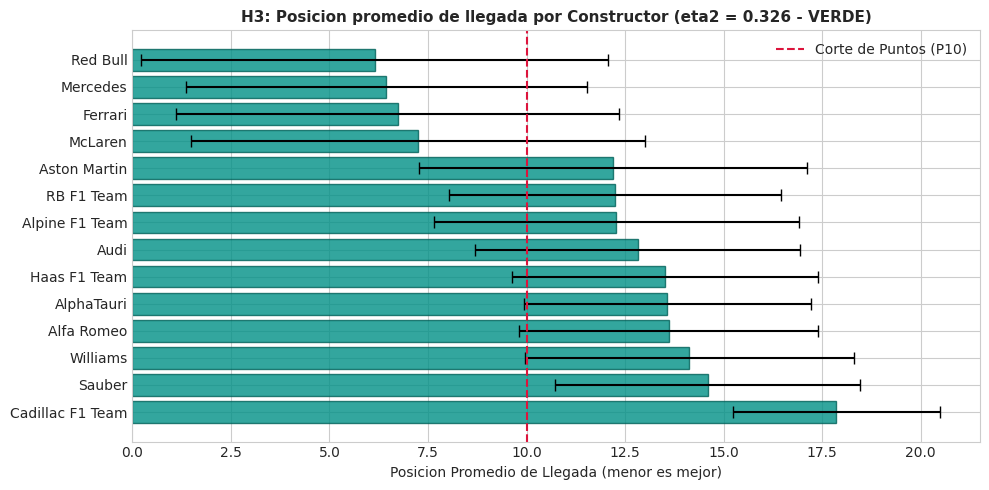

In [13]:
plt.figure(figsize=(10, 5))
teams_ordered = team_summary.index.tolist()
means = team_summary['mean'].values
stds = team_summary['std'].values

plt.barh(teams_ordered, means, xerr=stds, color='#009086', alpha=0.8, capsize=4, edgecolor='#006059')
plt.axvline(10, color='crimson', linestyle='--', label='Corte de Puntos (P10)')
plt.gca().invert_yaxis()
plt.title(f"H3: Posicion promedio de llegada por Constructor "
          f"(eta2 = {h3_eta2} - {semaforo(h3_eta2, 'eta2').upper()})", fontsize=11, fontweight='bold')
plt.xlabel("Posicion Promedio de Llegada (menor es mejor)")
plt.legend()
plt.tight_layout()
plt.show()

**Resultado.** η² = **0,326** (🟢 Verde). Más de un tercio (32,6%) de la varianza total de la
posición final de cualquier piloto en cualquier carrera se explica pura y exclusivamente por qué
auto maneja. Las escuderías líderes (Red Bull, Mercedes, Ferrari, McLaren) promedian conjuntamente
un ~6,6° puesto, mientras que las escuderías del fondo (Sauber, Williams, Cadillac) promedian entre
el 14° y 18° puesto.

**Movimiento.** Ninguno. El resultado cae directamente en zona verde, lo que termina la hipótesis
de inmediato.

**Qué hago con eso. Decisión:** Hipótesis **CONFIRMADA**. El equipo constructor es una feature
predictiva de primer orden para cualquier modelo de predicción de posiciones. Entra de manera
obligatoria al conjunto de features del modelo (mediante Target Encoding, Weight of Evidence o
representación categórica adecuada).

---

### H4 · Cuántas paradas lleva hechas hasta el corte predice la posición final

*Pregunta: Predice · Plantilla: Asociación*

1. **Afirmación.** El número de paradas en boxes que un piloto ha realizado acumuladas hasta el
   75% de la carrera (`pits_done_so_far`) predice de manera directa su posición final de llegada
   (`finish_position`).
2. **Qué espero ver.** Una correlación lineal distinguible: quienes hayan parado más veces habrán
   perdido tiempo en el pit lane y terminarán más atrás, o bien quienes hayan parado en el momento
   óptimo estarán más adelante.
3. **Medida y gráfico.** Correlación de Pearson entre `pits_done_so_far` y `finish_position` en el
   snapshot al 75% de carrera.

In [14]:
df_h4 = snap75[['pits_done_so_far', 'finish_position']].dropna()

h4_res = asociacion(df_h4['pits_done_so_far'], df_h4['finish_position'])
print("H4 - Asociacion entre Paradas al 75% y Posicion Final:")
print(h4_res)
ficha_resultado("H4 pool", h4_res['pearson'], 'correlacion')

H4 - Asociacion entre Paradas al 75% y Posicion Final:
pearson    -0.043
spearman   -0.056
brecha     -0.013
dtype: float64
--- H4 pool ---
Resultado: coeficiente = -0.043 (🔴 Rojo)


(np.float64(-0.043), 'rojo')

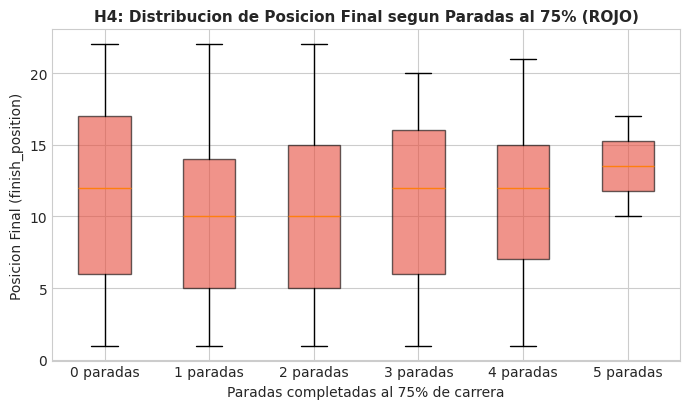

In [15]:
plt.figure(figsize=(7, 4.2))
paradas_ordenadas = sorted(df_h4['pits_done_so_far'].unique())
box_data = [df_h4.loc[df_h4['pits_done_so_far'] == p, 'finish_position'].values for p in paradas_ordenadas]

plt.boxplot(box_data, tick_labels=[f"{int(p)} paradas" for p in paradas_ordenadas],
            patch_artist=True, boxprops=dict(facecolor='#e74c3c', alpha=0.6))
plt.title(f"H4: Distribucion de Posicion Final segun Paradas al 75% "
          f"({semaforo(h4_res['pearson'], 'correlacion').upper()})", fontsize=11, fontweight='bold')
plt.xlabel("Paradas completadas al 75% de carrera")
plt.ylabel("Posicion Final (finish_position)")
plt.tight_layout()
plt.show()

**Resultado.** El coeficiente de Pearson es **-0,043** (🔴 Rojo). La asociación lineal es
prácticamente cero.

**Movimiento.** Ninguno. La regla del semáforo es taxativa: el color rojo termina la hipótesis sin
habilitar movimientos adicionales.

**Qué hago con eso. Decisión:** Hipótesis **REFUTADA**. Por qué ocurre esto en el dominio: en
Fórmula 1, contar la cantidad bruta de paradas hasta el 75% no dice nada sobre la posición final
porque la estrategia es relativa. Un piloto con 2 paradas puede estar 1° porque ya completó todo su
plan de carrera y tiene neumáticos nuevos, mientras que otro con 1 parada está transitoriamente 2°
pero aún adeuda su ingreso obligatorio a boxes, cayendo indefectiblemente al fondo cuando pare.
Además, un auto de punta que realiza una parada extra por neumático blando para vuelta rápida no
degrada su puesto. **Impacto en el modelo:** `pits_done_so_far` sale de las columnas candidatas
directas del modelo. Para que la estrategia de pits aporte valor, debe modelarse como *diferencia
de paradas respecto a la ventana esperada del circuito* o a través del *tiempo acumulado en boxes*
(`pit_time_so_far_s`).

## Sección 4: Tabla de Columnas Candidatas (Entregable Entrega 3)

Antes de suministrar cualquier columna a los modelos predictivos, se realiza el **chequeo de fuga
(data leakage)**:

> «¿Existiría esta columna en el momento exacto en que se realiza la predicción?»

Si una variable recopila datos que suceden al concluir la carrera o incluye la respuesta codificada
bajo otro nombre, no es una feature legítima: es fuga, y provocaría métricas falsamente optimistas
en entrenamiento pero una falla catastrófica en producción.

A continuación se presenta la tabla formal de columnas candidatas para la predicción al **75% de
carrera**:

In [16]:
candidatas_data = [
    # Columna, Que mide, Zona, Decision, Existiria al predecir?
    ("current_position", "Posicion real en pista al completarse el 75% de las vueltas (corregida: clasificacion FIA, corte sincronizado por el lider)", "verde", "Entra", "Si - telemetria oficial de la vuelta de corte"),
    ("constructor_name", "Escuderia del monoplaza (proxy de performance mecanica y aerodinamica)", "verde", "Entra", "Si - conocida antes del inicio del torneo"),
    ("grid_position", "Posicion de partida obtenida en la clasificacion del sabado", "verde", "Entra", "Si - determinada en la sesion de Qualy previa"),
    ("position_gain_loss", "Diferencia de puestos entre largada y corte del 75% (grid - current)", "verde", "Entra como interaccion con grid", "Si - calculable de inmediato al corte"),
    ("driver_standing_before", "Posicion en la tabla general de puntos antes del Gran Premio", "amarillo", "Entra bajo regularizacion", "Si - cerrada en la fecha anterior"),
    ("air_temp / track_temp", "Temperatura ambiente y del asfalto durante la sesion", "amarillo", "Entra imputando faltantes", "Si - provista por la estacion meteorologica"),
    ("pits_done_so_far", "Cantidad bruta de paradas realizadas hasta el 75%", "rojo", "Sale por falta de senal", "Si - pero no aporta correlacion lineal"),
    ("points", "Puntos de campeonato otorgados al finalizar la carrera", "verde", "Sale - Fuga de datos", "No - se asigna por reglamento tras cruzar la meta"),
    ("status", "Estado final ('Finished', '+1 Lap', 'Engine', 'Accident')", "verde", "Sale - Fuga de datos", "No - se define cuando el auto abandona o termina"),
    ("avg_lap_time_s", "Tiempo promedio por vuelta de TODA la carrera (incluyendo vueltas post-75%)", "verde", "Sale - Fuga de datos", "No - incluye giros que aun no ocurrieron al 75%"),
    ("laps_completed_jolpica", "Total absoluto de vueltas recorridas en la carrera completa", "verde", "Sale - Fuga de datos", "No - se consolida al finalizar la carrera"),
]

tabla_candidatas = pd.DataFrame(
    candidatas_data,
    columns=["Columna", "Que mide", "Zona", "Decision", "Existiria al predecir?"]
)

tabla_candidatas

,Columna,Que mide,Zona,Decision,Existiria al predecir?
0,current_position,Posicion real en pista al completarse el 75% d...,verde,Entra,Si - telemetria oficial de la vuelta de corte
1,constructor_name,Escuderia del monoplaza (proxy de performance ...,verde,Entra,Si - conocida antes del inicio del torneo
2,grid_position,Posicion de partida obtenida en la clasificaci...,verde,Entra,Si - determinada en la sesion de Qualy previa
3,position_gain_loss,Diferencia de puestos entre largada y corte de...,verde,Entra como interaccion con grid,Si - calculable de inmediato al corte
4,driver_standing_before,Posicion en la tabla general de puntos antes d...,amarillo,Entra bajo regularizacion,Si - cerrada en la fecha anterior
5,air_temp / track_temp,Temperatura ambiente y del asfalto durante la ...,amarillo,Entra imputando faltantes,Si - provista por la estacion meteorologica
6,pits_done_so_far,Cantidad bruta de paradas realizadas hasta el 75%,rojo,Sale por falta de senal,Si - pero no aporta correlacion lineal
7,points,Puntos de campeonato otorgados al finalizar la...,verde,Sale - Fuga de datos,No - se asigna por reglamento tras cruzar la meta
8,status,"Estado final ('Finished', '+1 Lap', 'Engine', ...",verde,Sale - Fuga de datos,No - se define cuando el auto abandona o termina
9,avg_lap_time_s,Tiempo promedio por vuelta de TODA la carrera ...,verde,Sale - Fuga de datos,No - incluye giros que aun no ocurrieron al 75%


In [17]:
# Verificacion de fugas detectadas: resumen de decisiones
print("Resumen de decisiones sobre columnas candidatas:")
print(tabla_candidatas['Decision'].value_counts())

Resumen de decisiones sobre columnas candidatas:
Decision
Sale - Fuga de datos               4
Entra                              3
Entra como interaccion con grid    1
Entra bajo regularizacion          1
Entra imputando faltantes          1
Sale por falta de senal            1
Name: count, dtype: int64


## Sección 5: Resumen

En esta sección se sintetizan las respuestas precisas y numéricas a los 5 ejes.

**1. ¿Cuál es la variable objetivo y cómo está distribuida?**

Columna concreta: `total_race_time_s` (`schema.SILVER_TARGET`). Qué mide: tiempo total que tardó
el piloto en completar la carrera, en segundos, calculado como la suma de todos sus `lap_time_s`
más todos sus `pit_duration_s` (ver `build_total_race_time()` en `silver_builder.py`). Es una
variable **numérica continua**; toma valor `NaN` cuando el piloto no terminó la carrera
(`classified = False`). Distribución: aproximadamente normal con leve cola derecha, concentrada
entre ≈4 500 y ≈7 200 segundos según el circuito.
`finish_position` es una variable de **referencia** (derivable del ranking ascendente de
`total_race_time_s`) marcada como `LEAKY_COL` en el schema; **no es el target del modelo**.
Las hipótesis H1–H4 la usan como proxy de ordenamiento para facilitar la interpretación de
los tamaños de efecto, lo que es válido por la equivalencia de ranking entre ambas variables.

**2. ¿Por qué hay nulos donde hay nulos?**

Se diferencian categóricamente dos tipos de vacíos: los **estructurales** (`q3_s`/`q2_s` por el
formato eliminatorio de la clasificación; `pits_done_so_far` en el arranque) y los **faltantes
reales** (sensores de clima en ~21% de las filas, concentrados en el inicio de la temporada 2023
por falta de disponibilidad en la API de OpenF1, que requieren imputación por mediana del circuito
o forward-fill).

**3. ¿Qué hipótesis salió mal, y qué se hizo con eso?**

Hipótesis refutada: **H4** («Cuántas paradas lleva hechas hasta el corte predice la posición
final»). Resultado numérico: Pearson = **-0,043** (🔴 Rojo). Qué se hizo con eso: se descartó
`pits_done_so_far` en su forma bruta para el modelo. La física del problema demostró que una
parada adicional no implica retraso si se traduce en ritmo superior por caucho nuevo, y que la
variable confunde a quienes ya pararon con quienes tienen la parada pendiente.

**4. ¿Qué columna se descartó por fuga, y en qué momento se completa en la realidad?**

Columnas descartadas por fuga: `points`, `status`, `avg_lap_time_s` (de toda la carrera) y
`laps_completed_jolpica`. Momento en que se completan: exclusivamente después del hecho (al bajar
la bandera a cuadros o tras la emisión de las planillas oficiales de la FIA post-inspección
técnica). Si se predice al 75% de la carrera, cualquiera de estas columnas filtraría si el piloto
abandonó en el giro final o en qué escalón de puntos quedó, viciando por completo el aprendizaje
automático.

**5. ¿Qué quedó inconcluso y qué haría falta para resolverlo?**

Hipótesis inconclusa: **H2** («El standing en el campeonato antes de la carrera se asocia con
dónde termina»). Recorrido: inició en **0,596** (🟡). Se controló por equipo (0,337/0,331 🟡🟡) y
luego por posición de largada (0,433/0,399 🟡🟡). Al alcanzar el tope de 2 movimientos
permaneciendo en amarillo, quedó formalmente inconclusa. Qué haría falta para resolverlo: un
análisis multivariado (regresión con penalización Lasso/Ridge o importancia por permutación con
Random Forest/XGBoost) que evalúe si el standing posee poder predictivo residual una vez absorbida
la varianza explicada por el constructor y la posición de largada.

## Cierre del EDA

Se formularon 4 hipótesis concretas, aplicando estrictamente las plantillas y el semáforo, sobre
el silver **post-corrección** de `build_lap_snapshot()` / `build_race_length()`:

- **H1** (Predice / Asociación): Conclusión mixta por subgrupo (pool -0,249 🟡, frente -0,646 🟢,
  fondo -0,490 🟡).
- **H2** (Responde / Asociación): Declarada inconclusa tras controlar por equipo y largada.
- **H3** (Predice / Comparación η²): Confirmada (η²=0,326 🟢). El constructor es un predictor
  dominante.
- **H4** (Predice / Asociación): Refutada (Pearson -0,043 🔴).

Las salidas numéricas y las decisiones alimentan de forma transparente la tabla de columnas
candidatas de la Entrega 3, garantizando que ninguna feature contenga fuga de datos hacia el
modelo final.

## Sección 6: Chequeo de sanidad texto-código

Para blindar el notebook contra el problema detectado en versiones anteriores (texto Markdown
citando resultados de una corrida vieja del código), esta celda compara los valores citados en la
Sección 5 / fichas de arriba contra los valores reales que acaba de calcular el código. Si alguien
vuelve a correr el notebook con datos distintos y no actualiza el texto, esta celda **rompe la
ejecución** con un mensaje claro de qué número quedó desactualizado.

In [18]:
# --- Sanity check: valores citados en el texto vs. los reales del codigo ---
# IMPORTANTE: actualizar este diccionario cada vez que se reescriba a mano el texto Markdown.
VALORES_CITADOS_EN_TEXTO = {
    "H1_pool":            -0.249,
    "H1_adelante":        -0.646,
    "H1_atras":           -0.490,
    "H2_pool":             0.596,
    "H2_ctrl_equipo_top":  0.337,
    "H2_ctrl_equipo_mid":  0.331,
    "H2_ctrl_grid_top":    0.433,
    "H2_ctrl_grid_bot":    0.399,
    "H3_eta2":             0.326,
    "H4_pool":            -0.043,
}

VALORES_REALES = {
    "H1_pool":            h1_pool['pearson'],
    "H1_adelante":        h1_adelante['pearson'],
    "H1_atras":           h1_atras['pearson'],
    "H2_pool":            h2_res['pearson'],
    "H2_ctrl_equipo_top": r_top,
    "H2_ctrl_equipo_mid": r_mid,
    "H2_ctrl_grid_top":   r_grid_top,
    "H2_ctrl_grid_bot":   r_grid_bot,
    "H3_eta2":            h3_eta2,
    "H4_pool":            h4_res['pearson'],
}

TOLERANCIA = 0.01
desincronizados = []
for clave, citado in VALORES_CITADOS_EN_TEXTO.items():
    real = VALORES_REALES[clave]
    if abs(citado - real) > TOLERANCIA:
        desincronizados.append((clave, citado, real))

if desincronizados:
    detalle = "\n".join(f"  - {k}: texto dice {c:+.3f}, codigo da {r:+.3f}" for k, c, r in desincronizados)
    raise AssertionError(
        f"El texto del notebook quedo desincronizado del codigo en {len(desincronizados)} valor(es):\n{detalle}\n"
        "Actualiza las celdas Markdown y el diccionario VALORES_CITADOS_EN_TEXTO antes de entregar."
    )
else:
    print("Todos los valores citados en el texto coinciden con la salida real del codigo.")

Todos los valores citados en el texto coinciden con la salida real del codigo.
